In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [2]:
data  = pd.read_csv("EURUSD_M15_2019-2025.csv", parse_dates = ['time'], index_col = 'time')

In [3]:
data = data[:'2021']

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 74731 entries, 2019-01-01 22:00:00 to 2021-12-31 21:45:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   74731 non-null  float64
 1   spread  74731 non-null  float64
dtypes: float64(2)
memory usage: 1.7 MB


In [5]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [6]:
window = 50

In [7]:
df = data.copy()
df["dir"] = np.where(df["returns"] > 0, 1, 0)
df["sma"] = df['price'].rolling(window).mean() - df['price'].rolling(150).mean()
df["boll"] = (df['price'] - df['price'].rolling(window).mean()) / df['price'].rolling(window).std()
df["min"] = df['price'].rolling(window).min() / df['price'] - 1
df["max"] = df['price'].rolling(window).max() / df['price'] - 1
df["mom"] = df["returns"].rolling(3).mean()
df["vol"] = df["returns"].rolling(window).std()
df.dropna(inplace = True)

In [8]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol
time,,,,,,,,,,
2019-01-03 11:15:00,1.13547,0.00014,-0.00017,0,-0.00337,-0.41014,-0.00372,0.00244,-0.00045,0.00063
2019-01-03 11:30:00,1.13498,0.00013,-0.00043,0,-0.00328,-0.76137,-0.00329,0.00287,-0.00055,0.00060
2019-01-03 11:45:00,1.13416,0.00015,-0.00072,0,-0.00320,-1.34227,-0.00257,0.00360,-0.00044,0.00061
2019-01-03 12:00:00,1.13437,0.00014,0.00019,1,-0.00310,-1.23208,-0.00275,0.00341,-0.00032,0.00061
2019-01-03 12:15:00,1.13482,0.00013,0.00040,1,-0.00295,-1.09565,-0.00099,0.00301,-0.00005,0.00054
...,...,...,...,...,...,...,...,...,...,...
2021-12-31 20:45:00,1.13758,0.00018,-0.00081,0,0.00232,0.87330,-0.00566,0.00092,-0.00025,0.00050
2021-12-31 21:00:00,1.13790,0.00018,0.00028,1,0.00242,0.96567,-0.00536,0.00064,-0.00013,0.00050
2021-12-31 21:15:00,1.13790,0.00016,0.00000,0,0.00250,0.92984,-0.00536,0.00064,-0.00018,0.00049


In [9]:
lags = 5

In [10]:
col = []
features = ["sma", "boll", "min", "max", "mom", "vol","dir"]
for feature in features:
    for lag in range(1, lags + 1):
        col.append(f"{feature}_lag{lag}")
        df[f"{feature}_lag{lag}"] = df[feature].shift(lag)
df.dropna(inplace = True)

In [11]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,1.13535,0.00012,0.00047,1,-0.00284,-0.71579,-0.00125,0.00255,0.00035,0.00045,...,0.00054,0.00061,0.00061,0.00060,0.00063,1.00000,1.00000,0.00000,0.00000,0.00000
2019-01-03 12:45:00,1.13436,0.00012,-0.00087,0,-0.00276,-1.56972,-0.00038,0.00342,-0.00000,0.00046,...,0.00045,0.00054,0.00061,0.00061,0.00060,1.00000,1.00000,1.00000,0.00000,0.00000
2019-01-03 13:00:00,1.13483,0.00044,0.00041,1,-0.00266,-1.21306,-0.00075,0.00300,0.00000,0.00046,...,0.00046,0.00045,0.00054,0.00061,0.00061,0.00000,1.00000,1.00000,1.00000,0.00000
2019-01-03 13:15:00,1.13506,0.00021,0.00020,1,-0.00257,-1.06133,-0.00079,0.00280,-0.00009,0.00046,...,0.00046,0.00046,0.00045,0.00054,0.00061,1.00000,0.00000,1.00000,1.00000,1.00000
2019-01-03 13:30:00,1.13574,0.00013,0.00060,1,-0.00248,-0.47358,-0.00139,0.00220,0.00041,0.00046,...,0.00046,0.00046,0.00046,0.00045,0.00054,1.00000,1.00000,0.00000,1.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 20:45:00,1.13758,0.00018,-0.00081,0,0.00232,0.87330,-0.00566,0.00092,-0.00025,0.00050,...,0.00048,0.00049,0.00049,0.00049,0.00049,1.00000,0.00000,1.00000,1.00000,0.00000
2021-12-31 21:00:00,1.13790,0.00018,0.00028,1,0.00242,0.96567,-0.00536,0.00064,-0.00013,0.00050,...,0.00050,0.00048,0.00049,0.00049,0.00049,0.00000,1.00000,0.00000,1.00000,1.00000
2021-12-31 21:15:00,1.13790,0.00016,0.00000,0,0.00250,0.92984,-0.00536,0.00064,-0.00018,0.00049,...,0.00050,0.00050,0.00048,0.00049,0.00049,1.00000,0.00000,1.00000,0.00000,1.00000


In [12]:
len(col)

35

In [13]:
len(df)

74577

In [14]:
# split = int(len(df)*0.66)
# split

In [15]:
train = df.loc["2019-01-01":"2020-12-31"].copy()
train

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,1.13535,0.00012,0.00047,1,-0.00284,-0.71579,-0.00125,0.00255,0.00035,0.00045,...,0.00054,0.00061,0.00061,0.00060,0.00063,1.00000,1.00000,0.00000,0.00000,0.00000
2019-01-03 12:45:00,1.13436,0.00012,-0.00087,0,-0.00276,-1.56972,-0.00038,0.00342,-0.00000,0.00046,...,0.00045,0.00054,0.00061,0.00061,0.00060,1.00000,1.00000,1.00000,0.00000,0.00000
2019-01-03 13:00:00,1.13483,0.00044,0.00041,1,-0.00266,-1.21306,-0.00075,0.00300,0.00000,0.00046,...,0.00046,0.00045,0.00054,0.00061,0.00061,0.00000,1.00000,1.00000,1.00000,0.00000
2019-01-03 13:15:00,1.13506,0.00021,0.00020,1,-0.00257,-1.06133,-0.00079,0.00280,-0.00009,0.00046,...,0.00046,0.00046,0.00045,0.00054,0.00061,1.00000,0.00000,1.00000,1.00000,1.00000
2019-01-03 13:30:00,1.13574,0.00013,0.00060,1,-0.00248,-0.47358,-0.00139,0.00220,0.00041,0.00046,...,0.00046,0.00046,0.00046,0.00045,0.00054,1.00000,1.00000,0.00000,1.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 20:45:00,1.22162,0.00016,0.00000,0,-0.00223,-1.32086,-0.00051,0.00696,0.00004,0.00048,...,0.00048,0.00048,0.00048,0.00048,0.00046,1.00000,1.00000,1.00000,0.00000,1.00000
2020-12-31 21:00:00,1.22269,0.00018,0.00088,1,-0.00233,-0.91377,-0.00138,0.00608,0.00030,0.00050,...,0.00048,0.00048,0.00048,0.00048,0.00048,0.00000,1.00000,1.00000,1.00000,0.00000
2020-12-31 21:15:00,1.22203,0.00018,-0.00054,0,-0.00246,-1.10649,-0.00084,0.00570,0.00011,0.00049,...,0.00050,0.00048,0.00048,0.00048,0.00048,1.00000,0.00000,1.00000,1.00000,1.00000


In [16]:
test = df.loc["2021-01-01":"2021-12-31"].copy()
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2021-01-03 22:00:00,1.22333,0.00100,0.00145,1,-0.00277,-0.52064,-0.00190,0.00439,0.00035,0.00051,...,0.00047,0.00047,0.00049,0.00050,0.00048,0.00000,0.00000,0.00000,1.00000,0.00000
2021-01-03 22:15:00,1.22387,0.00100,0.00044,1,-0.00284,-0.29838,-0.00235,0.00395,0.00054,0.00050,...,0.00051,0.00047,0.00047,0.00049,0.00050,1.00000,0.00000,0.00000,0.00000,1.00000
2021-01-03 22:30:00,1.22348,0.00039,-0.00032,0,-0.00292,-0.41355,-0.00203,0.00427,0.00052,0.00050,...,0.00050,0.00051,0.00047,0.00047,0.00049,1.00000,1.00000,0.00000,0.00000,0.00000
2021-01-03 22:45:00,1.22342,0.00063,-0.00005,0,-0.00300,-0.40772,-0.00198,0.00432,0.00002,0.00050,...,0.00050,0.00050,0.00051,0.00047,0.00047,0.00000,1.00000,1.00000,0.00000,0.00000
2021-01-03 23:00:00,1.22398,0.00025,0.00046,1,-0.00306,-0.16589,-0.00243,0.00386,0.00003,0.00051,...,0.00050,0.00050,0.00050,0.00051,0.00047,0.00000,0.00000,1.00000,1.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 20:45:00,1.13758,0.00018,-0.00081,0,0.00232,0.87330,-0.00566,0.00092,-0.00025,0.00050,...,0.00048,0.00049,0.00049,0.00049,0.00049,1.00000,0.00000,1.00000,1.00000,0.00000
2021-12-31 21:00:00,1.13790,0.00018,0.00028,1,0.00242,0.96567,-0.00536,0.00064,-0.00013,0.00050,...,0.00050,0.00048,0.00049,0.00049,0.00049,0.00000,1.00000,0.00000,1.00000,1.00000
2021-12-31 21:15:00,1.13790,0.00016,0.00000,0,0.00250,0.92984,-0.00536,0.00064,-0.00018,0.00049,...,0.00050,0.00050,0.00048,0.00049,0.00049,1.00000,0.00000,1.00000,0.00000,1.00000


In [17]:
train[col] 

,sma_lag1,sma_lag2,sma_lag3,sma_lag4,sma_lag5,boll_lag1,boll_lag2,boll_lag3,boll_lag4,boll_lag5,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,-0.00295,-0.00310,-0.00320,-0.00328,-0.00337,-1.09565,-1.23208,-1.34227,-0.76137,-0.41014,...,0.00054,0.00061,0.00061,0.00060,0.00063,1.00000,1.00000,0.00000,0.00000,0.00000
2019-01-03 12:45:00,-0.00284,-0.00295,-0.00310,-0.00320,-0.00328,-0.71579,-1.09565,-1.23208,-1.34227,-0.76137,...,0.00045,0.00054,0.00061,0.00061,0.00060,1.00000,1.00000,1.00000,0.00000,0.00000
2019-01-03 13:00:00,-0.00276,-0.00284,-0.00295,-0.00310,-0.00320,-1.56972,-0.71579,-1.09565,-1.23208,-1.34227,...,0.00046,0.00045,0.00054,0.00061,0.00061,0.00000,1.00000,1.00000,1.00000,0.00000
2019-01-03 13:15:00,-0.00266,-0.00276,-0.00284,-0.00295,-0.00310,-1.21306,-1.56972,-0.71579,-1.09565,-1.23208,...,0.00046,0.00046,0.00045,0.00054,0.00061,1.00000,0.00000,1.00000,1.00000,1.00000
2019-01-03 13:30:00,-0.00257,-0.00266,-0.00276,-0.00284,-0.00295,-1.06133,-1.21306,-1.56972,-0.71579,-1.09565,...,0.00046,0.00046,0.00046,0.00045,0.00054,1.00000,1.00000,0.00000,1.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 20:45:00,-0.00213,-0.00202,-0.00190,-0.00178,-0.00165,-1.37680,-1.44909,-1.55345,-1.78629,-1.44202,...,0.00048,0.00048,0.00048,0.00048,0.00046,1.00000,1.00000,1.00000,0.00000,1.00000
2020-12-31 21:00:00,-0.00223,-0.00213,-0.00202,-0.00190,-0.00178,-1.32086,-1.37680,-1.44909,-1.55345,-1.78629,...,0.00048,0.00048,0.00048,0.00048,0.00048,0.00000,1.00000,1.00000,1.00000,0.00000
2020-12-31 21:15:00,-0.00233,-0.00223,-0.00213,-0.00202,-0.00190,-0.91377,-1.32086,-1.37680,-1.44909,-1.55345,...,0.00050,0.00048,0.00048,0.00048,0.00048,1.00000,0.00000,1.00000,1.00000,1.00000


In [18]:
mu, std = train.mean(), train.std()

In [19]:
std

price       0.03463
spread      0.00010
returns     0.00044
dir         0.49998
sma         0.00213
boll        1.42049
min         0.00198
max         0.00199
mom         0.00025
vol         0.00022
sma_lag1    0.00213
sma_lag2    0.00213
sma_lag3    0.00213
sma_lag4    0.00213
sma_lag5    0.00213
boll_lag1   1.42049
boll_lag2   1.42049
boll_lag3   1.42049
boll_lag4   1.42049
boll_lag5   1.42048
min_lag1    0.00198
min_lag2    0.00198
min_lag3    0.00198
min_lag4    0.00198
min_lag5    0.00198
max_lag1    0.00199
max_lag2    0.00199
max_lag3    0.00199
max_lag4    0.00199
max_lag5    0.00199
mom_lag1    0.00025
mom_lag2    0.00025
mom_lag3    0.00025
mom_lag4    0.00025
mom_lag5    0.00025
vol_lag1    0.00022
vol_lag2    0.00022
vol_lag3    0.00022
vol_lag4    0.00022
vol_lag5    0.00022
dir_lag1    0.49998
dir_lag2    0.49998
dir_lag3    0.49998
dir_lag4    0.49998
dir_lag5    0.49998
dtype: float64

In [20]:
train_s = (train - mu) / std
train_s

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,0.13760,-0.34382,1.04819,1.00926,-1.37798,-0.52609,0.32205,0.37383,1.38566,0.27260,...,0.68459,1.00097,1.01819,0.99707,1.12024,1.00922,1.00918,-0.99088,-0.99084,-0.99084
2019-01-03 12:45:00,0.10901,-0.34382,-1.96792,-0.99080,-1.33784,-1.12724,0.76269,0.81366,-0.01765,0.33721,...,0.27259,0.68457,1.00095,1.01817,0.99705,1.00922,1.00918,1.00918,-0.99084,-0.99084
2019-01-03 13:00:00,0.12259,2.96773,0.92955,1.00926,-1.29288,-0.87616,0.57567,0.60476,0.00574,0.34850,...,0.33720,0.27258,0.68455,1.00094,1.01815,-0.99084,1.00918,1.00918,1.00922,-0.99084
2019-01-03 13:15:00,0.12923,0.58755,0.45304,1.00926,-1.24808,-0.76934,0.55348,0.50259,-0.34495,0.35190,...,0.34849,0.33719,0.27257,0.68454,1.00091,1.00922,-0.99088,1.00918,1.00922,1.00922
2019-01-03 13:30:00,0.14887,-0.24033,1.34541,1.00926,-1.20553,-0.35558,0.25105,0.20078,1.60743,0.34645,...,0.35190,0.34847,0.33717,0.27255,0.68451,1.00922,1.00918,-0.99088,1.00922,1.00922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 20:45:00,2.62909,0.07012,-0.00334,-0.99080,-1.09068,-0.95205,0.69775,2.59191,0.16786,0.43370,...,0.43473,0.43309,0.42809,0.40174,0.34981,1.00922,1.00918,1.00918,-0.99084,1.00922
2020-12-31 21:00:00,2.65999,0.27710,1.96831,1.00926,-1.13548,-0.66547,0.25559,2.14894,1.19930,0.52484,...,0.43369,0.43471,0.43308,0.42808,0.40172,-0.99084,1.00918,1.00918,1.00922,-0.99084
2020-12-31 21:15:00,2.64093,0.27710,-1.21930,-0.99080,-1.19665,-0.80113,0.52823,1.95726,0.43934,0.45330,...,0.52483,0.43368,0.43469,0.43307,0.42806,1.00922,-0.99088,1.00918,1.00922,1.00922


In [21]:
train_s.describe()

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
count,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,...,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000,49634.00000
mean,0.00000,0.00000,-0.00000,0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000,-0.00000,...,-0.00000,-0.00000,0.00000,0.00000,-0.00000,0.00000,-0.00000,-0.00000,0.00000,0.00000
std,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,...,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000
min,-1.92126,-0.55079,-15.60617,-0.99080,-5.70114,-4.33293,-7.24708,-0.90573,-11.64529,-1.47225,...,-1.47225,-1.47225,-1.47225,-1.47225,-1.47224,-0.99084,-0.99088,-0.99088,-0.99084,-0.99084
25%,-0.67653,-0.34382,-0.39062,-0.99080,-0.59270,-0.72638,-0.32798,-0.66462,-0.39617,-0.65386,...,-0.65387,-0.65387,-0.65388,-0.65388,-0.65389,-0.99084,-0.99088,-0.99088,-0.99084,-0.99084
50%,-0.24506,-0.24033,-0.00334,-0.99080,-0.03008,0.01429,0.31537,-0.28652,-0.00595,-0.22759,...,-0.22760,-0.22761,-0.22762,-0.22763,-0.22764,-0.99084,-0.99088,-0.99088,-0.99084,-0.99084
75%,0.36316,-0.13685,0.39657,1.00926,0.55804,0.74555,0.68458,0.31001,0.39419,0.36833,...,0.36841,0.36843,0.36841,0.36840,0.36838,1.00922,1.00918,1.00918,1.00922,1.00922
max,2.89306,8.76294,13.59128,1.00926,4.12889,4.24086,0.95431,11.45009,12.31696,7.51978,...,7.51975,7.51967,7.51960,7.51953,7.51944,1.00922,1.00918,1.00918,1.00922,1.00922


In [22]:
from DNNModel import *

In [23]:
# fitting a DNN model with 3 Hidden Layers (50 nodes each) and dropout regularization

set_seeds(100)
model = create_model(hl = 3, hu = 50, dropout = True, input_dim = len(col))
model.fit(x = train_s[col], y = train["dir"], epochs = 50, verbose = False,
          validation_split = 0.2, shuffle = False, class_weight = cw(train))

c:\Users\RAJ MANE\OneDrive\Desktop\XAI NOVELTY\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.evaluate(train_s[col], train["dir"])

1552/1552 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5308 - loss: 0.6908


[0.6908252835273743, 0.5308256149291992]

In [25]:
pred = model.predict(train_s[col])
pred

1552/1552 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


array([[0.4972726],
       [0.4876151],
       [0.5033667],
       ...,
       [0.4892565],
       [0.5317092],
       [0.5357218]], shape=(49634, 1), dtype=float32)

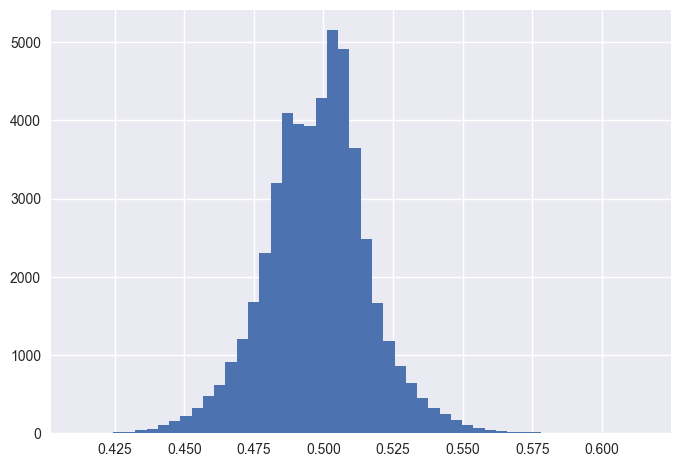

In [26]:
plt.hist(pred, bins = 50)
plt.show()

## Out-Sample Prediction and Forward Testing

In [27]:
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2021-01-03 22:00:00,1.22333,0.00100,0.00145,1,-0.00277,-0.52064,-0.00190,0.00439,0.00035,0.00051,...,0.00047,0.00047,0.00049,0.00050,0.00048,0.00000,0.00000,0.00000,1.00000,0.00000
2021-01-03 22:15:00,1.22387,0.00100,0.00044,1,-0.00284,-0.29838,-0.00235,0.00395,0.00054,0.00050,...,0.00051,0.00047,0.00047,0.00049,0.00050,1.00000,0.00000,0.00000,0.00000,1.00000
2021-01-03 22:30:00,1.22348,0.00039,-0.00032,0,-0.00292,-0.41355,-0.00203,0.00427,0.00052,0.00050,...,0.00050,0.00051,0.00047,0.00047,0.00049,1.00000,1.00000,0.00000,0.00000,0.00000
2021-01-03 22:45:00,1.22342,0.00063,-0.00005,0,-0.00300,-0.40772,-0.00198,0.00432,0.00002,0.00050,...,0.00050,0.00050,0.00051,0.00047,0.00047,0.00000,1.00000,1.00000,0.00000,0.00000
2021-01-03 23:00:00,1.22398,0.00025,0.00046,1,-0.00306,-0.16589,-0.00243,0.00386,0.00003,0.00051,...,0.00050,0.00050,0.00050,0.00051,0.00047,0.00000,0.00000,1.00000,1.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 20:45:00,1.13758,0.00018,-0.00081,0,0.00232,0.87330,-0.00566,0.00092,-0.00025,0.00050,...,0.00048,0.00049,0.00049,0.00049,0.00049,1.00000,0.00000,1.00000,1.00000,0.00000
2021-12-31 21:00:00,1.13790,0.00018,0.00028,1,0.00242,0.96567,-0.00536,0.00064,-0.00013,0.00050,...,0.00050,0.00048,0.00049,0.00049,0.00049,0.00000,1.00000,0.00000,1.00000,1.00000
2021-12-31 21:15:00,1.13790,0.00016,0.00000,0,0.00250,0.92984,-0.00536,0.00064,-0.00018,0.00049,...,0.00050,0.00050,0.00048,0.00049,0.00049,1.00000,0.00000,1.00000,0.00000,1.00000


In [28]:
test_s = (test - mu) / std
test_s

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2021-01-03 22:00:00,2.67848,8.76294,3.25741,1.00926,-1.34347,-0.38871,-0.00852,1.30087,1.40497,0.56332,...,0.36084,0.36077,0.45326,0.52479,0.43363,-0.99084,-0.99088,-0.99088,1.00922,-0.99084
2021-01-03 22:15:00,2.69407,8.76294,0.99052,1.00926,-1.37520,-0.23224,-0.23114,1.07810,2.13178,0.53025,...,0.56331,0.36082,0.36076,0.45325,0.52477,1.00922,-0.99088,-0.99088,-0.99084,1.00922
2021-01-03 22:30:00,2.68281,2.45030,-0.72109,-0.99080,-1.41330,-0.31332,-0.07038,1.23897,2.07815,0.51849,...,0.53024,0.56329,0.36081,0.36074,0.45323,1.00922,1.00918,-0.99088,-0.99084,-0.99084
2021-01-03 22:45:00,2.68108,4.93396,-0.11378,-0.99080,-1.44956,-0.30921,-0.04563,1.26373,0.09167,0.51688,...,0.51848,0.53022,0.56328,0.36080,0.36073,-0.99084,1.00918,1.00918,-0.99084,-0.99084
2021-01-03 23:00:00,2.69725,1.00150,1.02725,1.00926,-1.47866,-0.13897,-0.27646,1.03275,0.11331,0.54294,...,0.51688,0.51846,0.53021,0.56326,0.36078,-0.99084,-0.99088,1.00918,1.00922,-0.99084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 20:45:00,0.20201,0.27710,-1.82390,-0.99080,1.04564,0.59260,-1.90750,-0.44175,-0.98546,0.51278,...,0.43115,0.44929,0.45911,0.48849,0.49081,1.00922,-0.99088,1.00918,1.00922,-0.99084
2021-12-31 21:00:00,0.21125,0.27710,0.63006,1.00926,1.09175,0.65763,-1.75565,-0.58324,-0.53063,0.50481,...,0.51277,0.43114,0.44928,0.45910,0.48847,-0.99084,1.00918,-0.99088,1.00922,1.00922
2021-12-31 21:15:00,0.21125,0.07012,-0.00334,-0.99080,1.12920,0.63240,-1.75565,-0.58324,-0.70548,0.47996,...,0.50480,0.51275,0.43112,0.44926,0.45908,1.00922,-0.99088,1.00918,-0.99084,1.00922


In [29]:
model.evaluate(test_s[col], test["dir"])

780/780 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5188 - loss: 0.6923


[0.6922504901885986, 0.5187828540802002]

In [30]:
pred = model.predict(train_s[col])
pred

1552/1552 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


array([[0.4972726],
       [0.4876151],
       [0.5033667],
       ...,
       [0.4892565],
       [0.5317092],
       [0.5357218]], shape=(49634, 1), dtype=float32)

(array([3.000e+00, 5.000e+00, 4.000e+00, 1.100e+01, 2.000e+01, 4.300e+01,
        6.100e+01, 1.090e+02, 1.520e+02, 2.190e+02, 3.260e+02, 4.720e+02,
        6.120e+02, 9.120e+02, 1.208e+03, 1.675e+03, 2.305e+03, 3.202e+03,
        4.094e+03, 3.956e+03, 3.922e+03, 4.285e+03, 5.155e+03, 4.915e+03,
        3.642e+03, 2.486e+03, 1.671e+03, 1.176e+03, 8.610e+02, 6.380e+02,
        4.560e+02, 3.220e+02, 2.400e+02, 1.680e+02, 1.070e+02, 7.000e+01,
        4.400e+01, 2.700e+01, 1.900e+01, 1.000e+01, 1.000e+01, 5.000e+00,
        2.000e+00, 2.000e+00, 5.000e+00, 3.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00]),
 array([0.412157  , 0.41620725, 0.42025751, 0.42430776, 0.42835799,
        0.43240824, 0.4364585 , 0.44050875, 0.44455901, 0.44860926,
        0.45265949, 0.45670974, 0.46076   , 0.46481025, 0.46886051,
        0.47291076, 0.47696102, 0.48101124, 0.4850615 , 0.48911175,
        0.49316201, 0.49721226, 0.50126249, 0.50531274, 0.509363  ,
        0.51341325, 0.51746351, 0.52

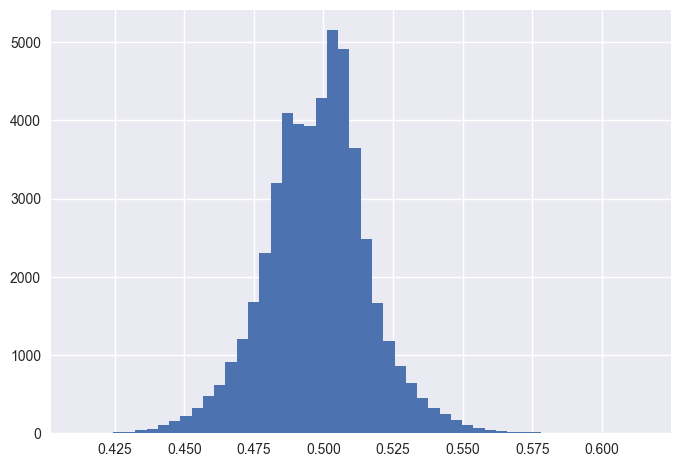

In [31]:
plt.hist(pred, bins = 50)

In [32]:
test['proba'] = model.predict(test_s[col])  

780/780 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [33]:
test["position"] = np.where(test.proba < 0.47, -1, np.nan) # 1. short where proba < 0.47

In [34]:
test["position"] = np.where(test.proba > 0.53, 1, test.position) # 2. long where proba > 0.53

In [35]:
test["hour"] = test.index.hour

In [36]:
test["position"] = np.where(~test.hour.between(12, 16), 0, test.position) # 3. neutral in non-busy hours

In [37]:
test["position"] = test.position.ffill().fillna(0) # 4. in all other cases: hold position

In [38]:
test.position.value_counts(dropna = False)

position
0.00000     21879
-1.00000     1601
1.00000      1463
Name: count, dtype: int64

In [39]:
test["strategy"] = test["position"] * test["returns"]

In [40]:
test["creturns"] = test["returns"].cumsum().apply(np.exp)
test["cstrategy"] = test["strategy"].cumsum().apply(np.exp)

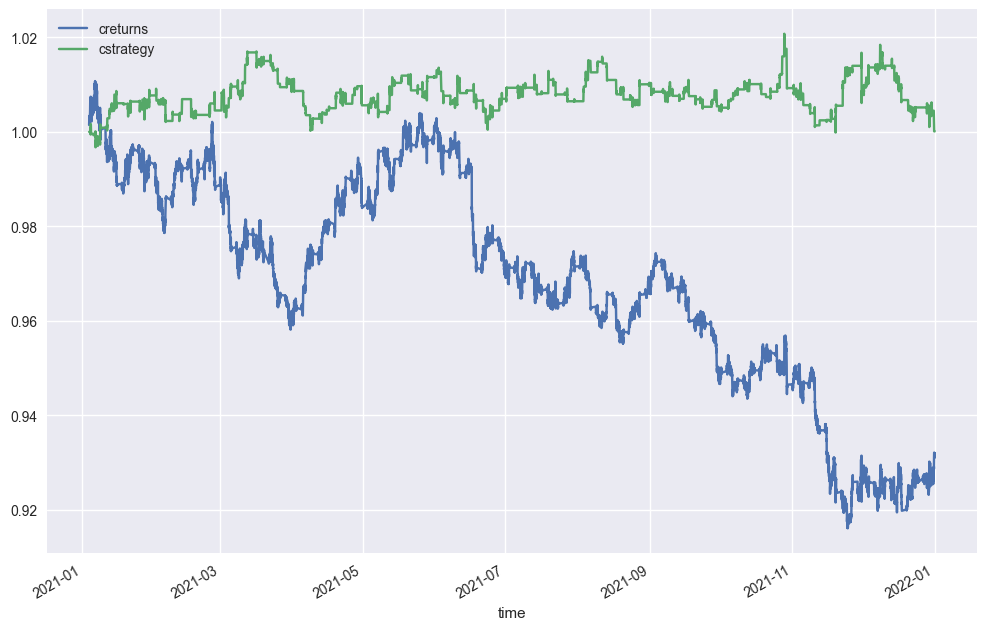

In [41]:
test[["creturns", "cstrategy"]].plot(figsize = (12, 8))
plt.show()

In [42]:
ptc = 0.00005 

In [43]:
test['trades'] = test.position.diff().abs()

In [44]:
test['trades'].value_counts()

trades
0.00000    24475
1.00000      420
2.00000       47
Name: count, dtype: int64

In [45]:
test['strategy_net'] = (test['strategy'] - test['trades'] * ptc).cumsum().apply(np.exp)

In [46]:
test['cstrategy_net'] = (test['strategy'] - test['trades'] * ptc).cumsum().apply(np.exp)

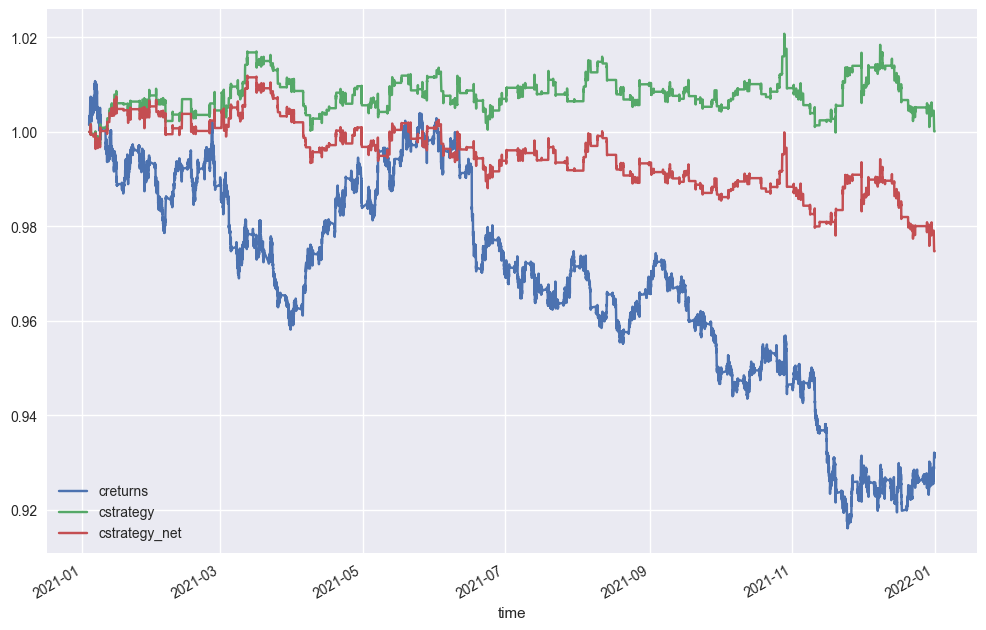

In [47]:
test[['creturns', 'cstrategy', 'cstrategy_net']].plot(figsize = (12, 8))
plt.show()


## XAI Decision Filtering Gate (SHAP)

This section adds a **risk-management gate** in front of the DNN’s trade decisions.

- The DNN produces a position signal (`test["position"]`) at every timestamp.
- A trade only happens when the position **changes** (captured by `test["trades"]`).
- The XAI gate runs **only at trade events** and uses **local SHAP feature importance** to decide whether a *new entry* is sufficiently well-explained.
- **Exits are always allowed** (reduces risk); **entries are filtered** (reduces low-quality / weakly-explained trades).

Outcome: we get a new position series `test["position_xai"]` and a net equity curve `test["cstrategy_net_xai"]` to compare against the baseline `test["cstrategy_net"]`.

In [48]:
# If needed:
# !pip install shap

import shap

# Gate hyperparameters (tune these)
TOP_N = 3
N_BACKGROUND = 200         # SHAP background sample size
N_CALIB = 800             # number of entry/flip events used to calibrate threshold
SHAP_QUANTILE = 0.60      # keep only the strongest ~25% explanations (higher => fewer trades)
PROBA_MARGIN = 0      # additional confidence margin around 0.5 for allowing entries
EXCLUDE_TOP1_PREFIXES = ("dir_",)  # treat these as weak/less-informative top drivers

# Build SHAP explainer on training distribution
background = train_s[col].sample(N_BACKGROUND, random_state=42).values
explainer = shap.DeepExplainer(model, background)


def _extract_shap_vector(shap_values):
    """Return a 1D SHAP vector for the (single) model output."""
    if isinstance(shap_values, list):
        arr = shap_values[0]
    else:
        arr = shap_values
    return np.array(arr).reshape(-1)


def _top_shap_summary(instance_1d, *, top_n=TOP_N):
    """Compute local SHAP summary for one instance."""
    instance_2d = instance_1d.reshape(1, -1)
    shap_values = explainer.shap_values(instance_2d, check_additivity=False)
    sv = _extract_shap_vector(shap_values)

    abs_sv = np.abs(sv)
    top_idx = np.argsort(abs_sv)[::-1][:top_n]
    top_features = [col[int(i)] for i in top_idx]
    top_shap = sv[top_idx]

    return {
        "sv": sv,
        "sv_sum": float(sv.sum()),
        "top_idx": top_idx,
        "top_features": top_features,
        "top_shap": [float(x) for x in top_shap],
        "top_abs": [float(x) for x in abs_sv[top_idx]],
        "top1_abs": float(abs_sv[top_idx[0]]),
    }


def calibrate_shap_threshold(test_df, test_scaled, *, quantile=SHAP_QUANTILE, n_calib=N_CALIB):
    """
    Calibrate an absolute-SHAP threshold from the distribution of top-1 SHAP magnitudes
    on (a sample of) entry/flip events.

    Higher threshold => fewer trades (stricter risk filter).
    """
    # Events where the baseline strategy changes position AND desires a non-zero position
    trade_event = test_df["trades"].fillna(0) > 0
    entry_like = trade_event & (test_df["position"].fillna(0) != 0)
    event_idx = test_df.index[entry_like]

    if len(event_idx) == 0:
        return 0.0

    # Sample for speed
    if len(event_idx) > n_calib:
        event_idx = event_idx[:n_calib]

    top1_abs_list = []
    for idx in event_idx:
        instance = test_scaled.loc[idx, col].values
        summ = _top_shap_summary(instance, top_n=TOP_N)
        top1_abs_list.append(summ["top1_abs"])

    thr = float(np.quantile(np.array(top1_abs_list), quantile))
    return thr


def xai_gate_entry(instance_1d, desired_pos, proba, *, shap_threshold, top_n=TOP_N):
    """
    Decide whether to ALLOW a *new entry* (desired_pos in {-1, +1}) based on local SHAP.

    Checks:
    - confidence: proba must be far enough from 0.5 (PROBA_MARGIN)
    - explanation strength: top-1 |SHAP| must exceed calibrated shap_threshold
    - explanation direction: sum(SHAP) should align with desired direction
    - explanation quality: avoid trivial top driver(s) like dir_lag* (optional)

    Returns: allow(bool), info(dict)
    """
    desired_pos = int(desired_pos)
    proba = float(proba)

    # Confidence check (acts like a second-stage filter)
    if desired_pos == 1:
        proba_ok = proba >= (0.5 + PROBA_MARGIN)
    else:
        proba_ok = proba <= (0.5 - PROBA_MARGIN)

    summ = _top_shap_summary(instance_1d, top_n=top_n)
    sv_sum = summ["sv_sum"]

    direction_ok = (desired_pos == 1 and sv_sum > 0) or (desired_pos == -1 and sv_sum < 0)
    magnitude_ok = summ["top1_abs"] >= float(shap_threshold)

    top1 = summ["top_features"][0]
    top1_ok = not any(top1.startswith(p) for p in EXCLUDE_TOP1_PREFIXES)

    allow = bool(proba_ok and direction_ok and magnitude_ok and top1_ok)

    info = {
        "proba": proba,
        "desired_pos": desired_pos,
        "sv_sum": sv_sum,
        "top_features": summ["top_features"],
        "top_shap": summ["top_shap"],
        "top_abs": summ["top_abs"],
        "top1_abs": summ["top1_abs"],
        "proba_ok": bool(proba_ok),
        "direction_ok": bool(direction_ok),
        "magnitude_ok": bool(magnitude_ok),
        "top1_ok": bool(top1_ok),
        "shap_threshold": float(shap_threshold),
    }
    return allow, info


def format_gate_explanation(prev_pos, desired_pos, final_pos, info, allow):
    tf = info.get("top_features", [])
    ts = info.get("top_shap", [])
    parts = [
        f"prev={prev_pos}, desired={desired_pos}, final={final_pos}",
        f"proba={info.get('proba', np.nan):.3f}, shap_sum={info.get('sv_sum', np.nan):+.4f}, top1_abs={info.get('top1_abs', np.nan):.4f}",
        f"shap_threshold={info.get('shap_threshold', np.nan):.4f}",
        "top features: " + ", ".join([f"{f}({v:+.4f})" for f, v in zip(tf, ts)]),
        f"checks: proba={info.get('proba_ok')} direction={info.get('direction_ok')} magnitude={info.get('magnitude_ok')} top1_ok={info.get('top1_ok')}",
        "DECISION: " + ("ALLOW" if allow else "DENY"),
    ]
    return "\n".join(parts)

c:\Users\RAJ MANE\OneDrive\Desktop\XAI NOVELTY\venv\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\RAJ MANE\OneDrive\Desktop\XAI NOVELTY\venv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 35))']
  warnings.warn(msg)


In [49]:
# Apply XAI gate only when the baseline strategy would trade
pos_target = test["position"].copy()

# ---------------------------
# FIX FOR DATA LEAKAGE / SNOOPING
# ---------------------------
# DO NOT calibrate SHAP threshold on the test set.
# Instead, calibrate on a "calibration" slice taken from the training period.
# This keeps the test year purely out-of-sample for the XAI gate evaluation.

CALIB_FRAC = 0.20  # last 20% of train used for calibration
calib_start = int(len(train) * (1 - CALIB_FRAC))
calib = train.iloc[calib_start:].copy()
calib_s = (calib - mu) / std

# Build baseline signals on calibration slice (same rules as test baseline)
PROBA_SHORT = 0.47
PROBA_LONG = 0.53
BUSY_HOUR_START = 12
BUSY_HOUR_END = 16

calib["proba"] = model.predict(calib_s[col])
calib["position"] = np.where(calib.proba < PROBA_SHORT, -1, np.nan)
calib["position"] = np.where(calib.proba > PROBA_LONG, 1, calib.position)
calib["hour"] = calib.index.hour
calib["position"] = np.where(~calib.hour.between(BUSY_HOUR_START, BUSY_HOUR_END), 0, calib.position)
calib["position"] = calib.position.ffill().fillna(0)
calib["trades"] = calib.position.diff().abs().fillna(0)

# Calibrate SHAP threshold from entry/flip events in CALIBRATION slice (not test)
SHAP_THRESHOLD = calibrate_shap_threshold(calib, calib_s, quantile=SHAP_QUANTILE, n_calib=N_CALIB)
print("Calibrated SHAP_THRESHOLD (from TRAIN calibration slice):", SHAP_THRESHOLD)

# Construct position_xai sequentially:
# - Exits to 0 are always allowed
# - Entries to +/-1 are filtered by SHAP + confidence checks
# - Flips become: exit (allowed) then optional entry (gated)

position_xai = pd.Series(index=test.index, dtype=float)
position_xai.iloc[0] = float(pos_target.iloc[0])

trade_event = test["trades"].fillna(0) > 0

gate_log = []

for i in range(1, len(test)):
    idx = test.index[i]
    prev = float(position_xai.iloc[i - 1])
    desired = float(pos_target.iloc[i])

    # Default: hold
    final_pos = prev
    action = "hold"
    allow = True

    proba = float(test.loc[idx, "proba"])
    info = {"proba": proba, "desired_pos": int(desired), "sv_sum": np.nan, "top_features": [], "top_shap": [], "top_abs": [], "top1_abs": np.nan, "proba_ok": True, "direction_ok": True, "magnitude_ok": True, "top1_ok": True, "shap_threshold": float(SHAP_THRESHOLD)}

    if trade_event.iloc[i]:
        # Model wants to change position here
        if desired == 0:
            action = "exit"
            final_pos = 0.0
            allow = True

        elif prev != 0 and np.sign(prev) != np.sign(desired):
            # Flip: always exit; entry is gated
            action = "flip"
            instance = test_s.loc[idx, col].values
            allow_entry, info = xai_gate_entry(instance, int(desired), proba, shap_threshold=SHAP_THRESHOLD, top_n=TOP_N)
            allow = allow_entry
            final_pos = float(desired) if allow_entry else 0.0

        else:
            # Entry from flat, or re-entry after being flat
            action = "entry"
            instance = test_s.loc[idx, col].values
            allow_entry, info = xai_gate_entry(instance, int(desired), proba, shap_threshold=SHAP_THRESHOLD, top_n=TOP_N)
            allow = allow_entry
            final_pos = float(desired) if allow_entry else prev

    position_xai.iloc[i] = final_pos

    if trade_event.iloc[i]:
        gate_log.append({
            "time": idx,
            "action": action,
            "prev_pos": prev,
            "desired_pos": desired,
            "final_pos": final_pos,
            "allow": bool(allow),
            "proba": info.get("proba", np.nan),
            "sv_sum": info.get("sv_sum", np.nan),
            "top1": info.get("top_features", [None])[0] if info.get("top_features") else None,
            "top1_abs": info.get("top1_abs", np.nan),
            "top1_shap": info.get("top_shap", [np.nan])[0] if info.get("top_shap") else np.nan,
            "proba_ok": info.get("proba_ok", True),
            "direction_ok": info.get("direction_ok", True),
            "magnitude_ok": info.get("magnitude_ok", True),
            "top1_ok": info.get("top1_ok", True),
            "shap_threshold": info.get("shap_threshold", np.nan),
            "explanation": format_gate_explanation(prev, desired, final_pos, info, allow),
        })

# Attach to test
position_xai = position_xai.ffill().fillna(0)
test["position_xai"] = position_xai

# Trades and performance with gate
test["trades_xai"] = test["position_xai"].diff().abs().fillna(0)
test["strategy_xai"] = test["position_xai"] * test["returns"]
test["cstrategy_xai"] = test["strategy_xai"].cumsum().apply(np.exp)
test["cstrategy_net_xai"] = (test["strategy_xai"] - test["trades_xai"] * ptc).cumsum().apply(np.exp)

# Gate log table
gate_log_df = pd.DataFrame(gate_log).set_index("time")
gate_log_df.head()

311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


c:\Users\RAJ MANE\OneDrive\Desktop\XAI NOVELTY\venv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(400, 35))']
  warnings.warn(msg)


Calibrated SHAP_THRESHOLD (from TRAIN calibration slice): 0.013661200822430834


,action,prev_pos,desired_pos,final_pos,allow,proba,sv_sum,top1,top1_abs,top1_shap,proba_ok,direction_ok,magnitude_ok,top1_ok,shap_threshold,explanation
time,,,,,,,,,,,,,,,,
2021-01-04 12:30:00,entry,0.00000,-1.00000,0.00000,False,0.46736,-0.03221,min_lag1,0.01050,-0.01050,True,True,False,True,0.01366,"prev=0.0, desired=-1.0, final=0.0\nproba=0.467..."
2021-01-04 15:15:00,entry,0.00000,1.00000,1.00000,True,0.53700,0.03743,mom_lag1,0.01464,0.01464,True,True,True,True,0.01366,"prev=0.0, desired=1.0, final=1.0\nproba=0.537,..."
2021-01-04 17:00:00,exit,1.00000,0.00000,0.00000,True,0.52565,NaN,None,NaN,NaN,True,True,True,True,0.01366,"prev=1.0, desired=0.0, final=0.0\nproba=0.526,..."
2021-01-05 16:45:00,entry,0.00000,-1.00000,0.00000,False,0.46395,-0.03561,boll_lag1,0.00964,-0.00964,True,True,False,True,0.01366,"prev=0.0, desired=-1.0, final=0.0\nproba=0.464..."
2021-01-05 17:00:00,exit,0.00000,0.00000,0.00000,True,0.46481,NaN,None,NaN,NaN,True,True,True,True,0.01366,"prev=0.0, desired=0.0, final=0.0\nproba=0.465,..."


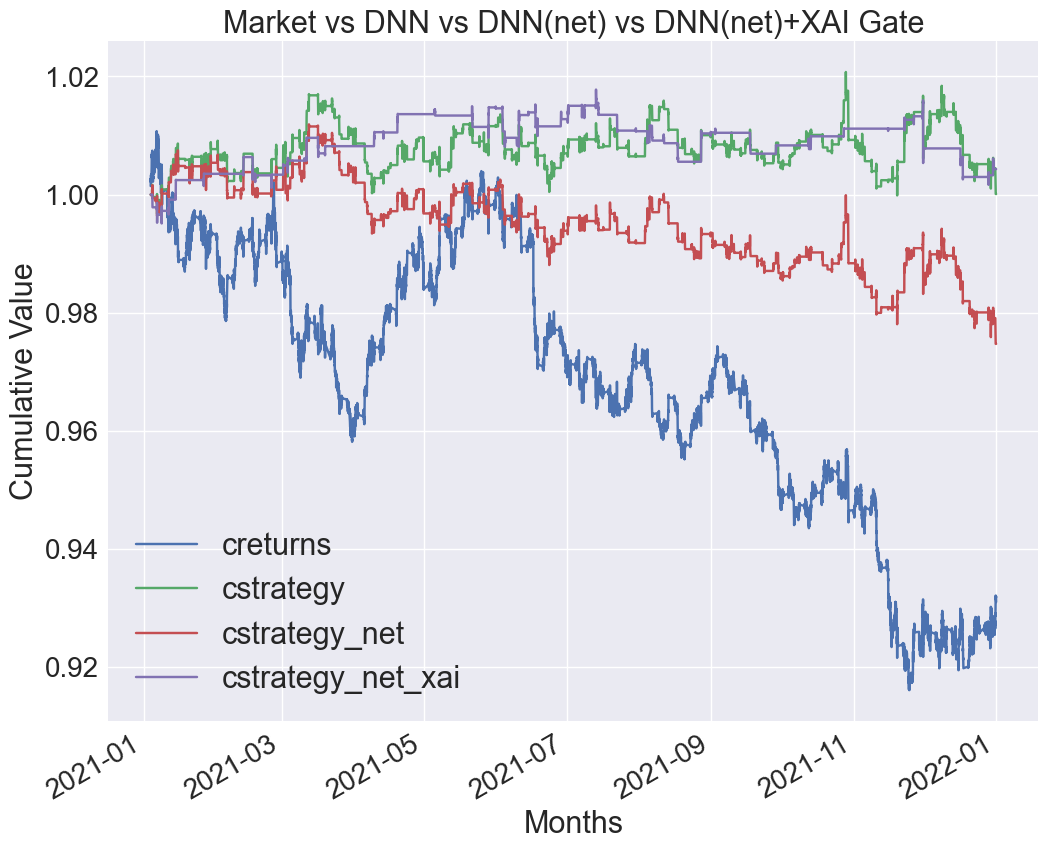

Baseline (net) ending value: 0.9747267980779154
XAI-gated (net) ending value: 1.0043191596594963
Baseline orders (sum abs pos change): 514.0
XAI orders (sum abs pos change): 124.0
Baseline trade events (bars with orders): 467
XAI trade events (bars with orders): 121
Gate evaluated events: 467
Gate allowed events: 272
Gate denied events: 195
Order reduction vs baseline: 75.88%


In [65]:
# Compare baseline vs XAI-gated strategy (net of trading costs)
compare_cols = ["creturns", "cstrategy", "cstrategy_net", "cstrategy_net_xai"]
test[compare_cols].plot(figsize=(12, 10),fontsize=20)
plt.title("Market vs DNN vs DNN(net) vs DNN(net)+XAI Gate",fontsize=22)
plt.legend(fontsize=22)
plt.xlabel("Months",fontsize=22)
plt.ylabel("Cumulative Value",fontsize=22)
plt.show()

# Trade counts and gate stats
baseline_orders = float(test["trades"].fillna(0).sum())
xai_orders = float(test["trades_xai"].fillna(0).sum())
baseline_trade_events = int((test["trades"].fillna(0) > 0).sum())
xai_trade_events = int((test["trades_xai"].fillna(0) > 0).sum())

allowed = int(gate_log_df["allow"].sum())
denied = int((~gate_log_df["allow"]).sum())

print("Baseline (net) ending value:", float(test["cstrategy_net"].iloc[-1]))
print("XAI-gated (net) ending value:", float(test["cstrategy_net_xai"].iloc[-1]))
print("Baseline orders (sum abs pos change):", baseline_orders)
print("XAI orders (sum abs pos change):", xai_orders)
print("Baseline trade events (bars with orders):", baseline_trade_events)
print("XAI trade events (bars with orders):", xai_trade_events)
print("Gate evaluated events:", len(gate_log_df))
print("Gate allowed events:", allowed)
print("Gate denied events:", denied)

# How XAI acts as risk management
reduction = 0 if baseline_orders == 0 else 1 - (xai_orders / baseline_orders)
print("Order reduction vs baseline:", f"{reduction:.2%}")

In [51]:
# Show sample trade decisions with explanations

# Sample a few allowed and denied events (if available)
allowed_samples = gate_log_df[gate_log_df["allow"]].head(5)
denied_samples = gate_log_df[~gate_log_df["allow"]].head(5)

print("\n--- Sample ALLOWED decisions (first 5) ---")
for t, row in allowed_samples.iterrows():
    print("\nTime:", t)
    print(row["explanation"])

print("\n--- Sample DENIED decisions (first 5) ---")
for t, row in denied_samples.iterrows():
    print("\nTime:", t)
    print(row["explanation"])

# Compact table view
cols_view = ["action", "prev_pos", "desired_pos", "final_pos", "allow", "proba", "sv_sum", "top1", "top1_shap"]
gate_log_df[cols_view].head(20)


--- Sample ALLOWED decisions (first 5) ---

Time: 2021-01-04 15:15:00
prev=0.0, desired=1.0, final=1.0
proba=0.537, shap_sum=+0.0374, top1_abs=0.0146
shap_threshold=0.0137
top features: mom_lag1(+0.0146), dir_lag1(+0.0075), min_lag5(+0.0058)
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2021-01-04 17:00:00
prev=1.0, desired=0.0, final=0.0
proba=0.526, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0137
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2021-01-05 17:00:00
prev=0.0, desired=0.0, final=0.0
proba=0.465, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0137
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2021-01-06 14:15:00
prev=0.0, desired=1.0, final=1.0
proba=0.543, shap_sum=+0.0437, top1_abs=0.0151
shap_threshold=0.0137
top features: mom_lag1(+0.0151), dir_lag1(+0.0066), min_lag5(+0.0055)
checks: proba=True direction=True magnitude=True

,action,prev_pos,desired_pos,final_pos,allow,proba,sv_sum,top1,top1_shap
time,,,,,,,,,
2021-01-04 12:30:00,entry,0.00000,-1.00000,0.00000,False,0.46736,-0.03221,min_lag1,-0.01050
2021-01-04 15:15:00,entry,0.00000,1.00000,1.00000,True,0.53700,0.03743,mom_lag1,0.01464
2021-01-04 17:00:00,exit,1.00000,0.00000,0.00000,True,0.52565,NaN,None,NaN
2021-01-05 16:45:00,entry,0.00000,-1.00000,0.00000,False,0.46395,-0.03561,boll_lag1,-0.00964
2021-01-05 17:00:00,exit,0.00000,0.00000,0.00000,True,0.46481,NaN,None,NaN
2021-01-06 14:15:00,entry,0.00000,1.00000,1.00000,True,0.54328,0.04371,mom_lag1,0.01510
2021-01-06 17:00:00,exit,1.00000,0.00000,0.00000,True,0.49438,NaN,None,NaN
2021-01-07 14:00:00,entry,0.00000,1.00000,0.00000,False,0.54809,0.04853,dir_lag1,0.00922
2021-01-07 17:00:00,exit,0.00000,0.00000,0.00000,True,0.54778,NaN,None,NaN


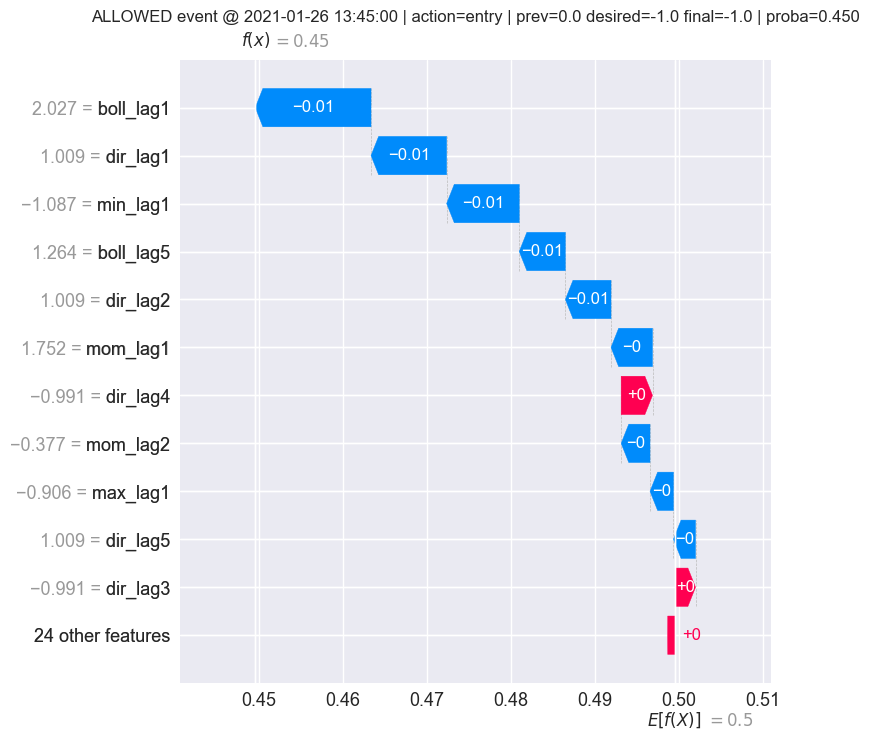


--- Explanation (ALLOWED entry/flip) ---
prev=0.0, desired=-1.0, final=-1.0
proba=0.450, shap_sum=-0.0500, top1_abs=0.0138
shap_threshold=0.0137
top features: boll_lag1(-0.0138), dir_lag1(-0.0090), min_lag1(-0.0086)
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW


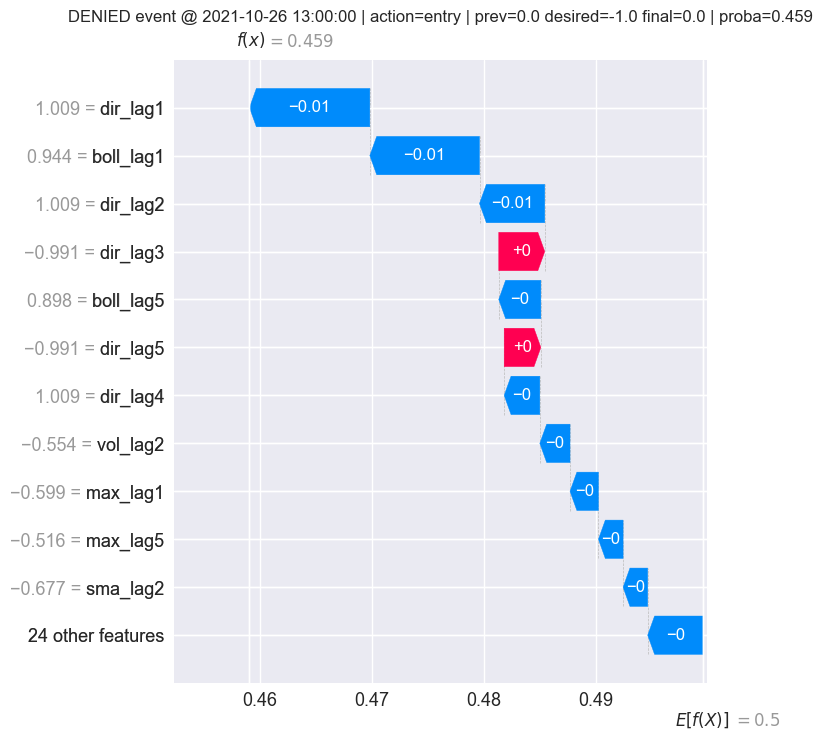


--- Explanation (DENIED entry/flip) ---
prev=0.0, desired=-1.0, final=0.0
proba=0.459, shap_sum=-0.0405, top1_abs=0.0108
shap_threshold=0.0137
top features: dir_lag1(-0.0108), boll_lag1(-0.0098), dir_lag2(-0.0058)
checks: proba=True direction=True magnitude=False top1_ok=False
DECISION: DENY


In [66]:
# Waterfall plots: one random ALLOWED entry/flip and one random DENIED entry/flip

def _get_expected_value(exp):
    ev = getattr(exp, "expected_value", 0.0)
    if isinstance(ev, (list, tuple, np.ndarray)):
        ev = ev[0]
    return float(np.array(ev).reshape(()))


def waterfall_for_event(event_time, label):
    x = test_s.loc[event_time, col].values
    shap_values = explainer.shap_values(x.reshape(1, -1), check_additivity=False)
    sv = _extract_shap_vector(shap_values)
    base = _get_expected_value(explainer)

    exp = shap.Explanation(
        values=sv,
        base_values=base,
        data=x,
        feature_names=col,
    )

    meta = gate_log_df.loc[event_time]
    title = (
        f"{label} event @ {event_time} | action={meta['action']} | "
        f"prev={meta['prev_pos']} desired={meta['desired_pos']} final={meta['final_pos']} | proba={meta['proba']:.3f}"
    )

    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp, max_display=12, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(42)

# We want cases where the gate actually matters: entries or flips (not exits)
entry_like = gate_log_df["action"].isin(["entry", "flip"]) & (gate_log_df["desired_pos"].astype(float) != 0)

allowed_candidates = gate_log_df[entry_like & (gate_log_df["allow"])].index

denied_candidates = gate_log_df[entry_like & (~gate_log_df["allow"])].index

if len(allowed_candidates) > 0:
    t_allowed = allowed_candidates[rng.integers(0, len(allowed_candidates))]
    waterfall_for_event(t_allowed, "ALLOWED")
    print("\n--- Explanation (ALLOWED entry/flip) ---")
    print(gate_log_df.loc[t_allowed, "explanation"])
else:
    print("No ALLOWED entry/flip events available to plot.")

if len(denied_candidates) > 0:
    t_denied = denied_candidates[rng.integers(0, len(denied_candidates))]
    waterfall_for_event(t_denied, "DENIED")
    print("\n--- Explanation (DENIED entry/flip) ---")
    print(gate_log_df.loc[t_denied, "explanation"])
else:
    print("No DENIED entry/flip events available to plot.")

## Additional XAI Visualisations (MSc-ready)

This block produces four groups of figures:

1) **Global feature importance** (SHAP beeswarm + bar)
2) **Local explanations** (already shown above via waterfall plots)
3) **Gate behavior summary** (allowed vs denied distributions + top-driver frequency)
4) **Regime / time stability** (rolling mean absolute SHAP for top features)

Notes:
- SHAP for deep models is compute-heavy. These cells intentionally compute SHAP on a **sample** to keep runtime practical.
- To make results reproducible, a fixed RNG seed is used for sampling.

In [67]:
# ---- SHAP sampling utilities (used by multiple plots) ----

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Control how many points to explain (trade-off: quality vs runtime)
GLOBAL_SHAP_SAMPLES = 1200      # for global beeswarm+bar
REGIME_SHAP_SAMPLES = 2000      # for rolling stability
SHAP_BATCH = 200                # batch size for explainer

# Choose where to sample from:
# - For "global" interpretation across all timestamps, sample from test_s.
# - For "trade-centric" interpretation, sample from trade events only.
USE_TRADE_EVENTS_FOR_GLOBAL = False


def _extract_shap_matrix(shap_values):
    """Return a (n_samples, n_features) matrix from DeepExplainer output."""
    if isinstance(shap_values, list):
        arr = shap_values[0]
    else:
        arr = shap_values
    return np.array(arr)


def compute_shap_for_index(index, *, batch_size=SHAP_BATCH):
    """
    Compute SHAP values for rows in `index` using `test_s[col]` and the global `explainer`.
    Returns: X (n, d), S (n, d)
    """
    X = test_s.loc[index, col].values
    S_chunks = []

    for start in range(0, len(index), batch_size):
        end = min(start + batch_size, len(index))
        xb = X[start:end]
        sv = explainer.shap_values(xb, check_additivity=False)
        S_chunks.append(_extract_shap_matrix(sv))

    S = np.vstack(S_chunks) if len(S_chunks) else np.empty((0, len(col)))
    return X, S


def _sample_index_from_pool(pool_index, n):
    pool_index = np.array(pool_index)
    if len(pool_index) <= n:
        return pool_index
    take = rng.choice(len(pool_index), size=n, replace=False)
    return pool_index[take]


# Build sampling pools
trade_event_idx = gate_log_df.index  # when the baseline strategy changed position
all_test_idx = test.index

global_pool = trade_event_idx if USE_TRADE_EVENTS_FOR_GLOBAL else all_test_idx

# Samples for plots
idx_global = _sample_index_from_pool(global_pool, GLOBAL_SHAP_SAMPLES)
idx_regime = _sample_index_from_pool(trade_event_idx, REGIME_SHAP_SAMPLES)

print("Global SHAP sample size:", len(idx_global), "(trade-centric:" , USE_TRADE_EVENTS_FOR_GLOBAL, ")")
print("Regime SHAP sample size:", len(idx_regime), "(trade-event-only)")

Global SHAP sample size: 1200 (trade-centric: False )
Regime SHAP sample size: 467 (trade-event-only)


In [54]:
model

<Sequential name=sequential, built=True>

In [55]:
mu

price        1.13059
spread       0.00015
returns      0.00000
dir          0.49539
sma          0.00009
boll         0.03152
min         -0.00189
max          0.00180
mom          0.00000
vol          0.00039
sma_lag1     0.00009
sma_lag2     0.00009
sma_lag3     0.00009
sma_lag4     0.00009
sma_lag5     0.00009
boll_lag1    0.03152
boll_lag2    0.03151
boll_lag3    0.03151
boll_lag4    0.03151
boll_lag5    0.03153
min_lag1    -0.00189
min_lag2    -0.00189
min_lag3    -0.00189
min_lag4    -0.00189
min_lag5    -0.00189
max_lag1     0.00180
max_lag2     0.00180
max_lag3     0.00180
max_lag4     0.00180
max_lag5     0.00180
mom_lag1     0.00000
mom_lag2     0.00000
mom_lag3     0.00000
mom_lag4     0.00000
mom_lag5     0.00000
vol_lag1     0.00039
vol_lag2     0.00039
vol_lag3     0.00039
vol_lag4     0.00039
vol_lag5     0.00039
dir_lag1     0.49541
dir_lag2     0.49543
dir_lag3     0.49543
dir_lag4     0.49541
dir_lag5     0.49541
dtype: float64

In [56]:
std

price       0.03463
spread      0.00010
returns     0.00044
dir         0.49998
sma         0.00213
boll        1.42049
min         0.00198
max         0.00199
mom         0.00025
vol         0.00022
sma_lag1    0.00213
sma_lag2    0.00213
sma_lag3    0.00213
sma_lag4    0.00213
sma_lag5    0.00213
boll_lag1   1.42049
boll_lag2   1.42049
boll_lag3   1.42049
boll_lag4   1.42049
boll_lag5   1.42048
min_lag1    0.00198
min_lag2    0.00198
min_lag3    0.00198
min_lag4    0.00198
min_lag5    0.00198
max_lag1    0.00199
max_lag2    0.00199
max_lag3    0.00199
max_lag4    0.00199
max_lag5    0.00199
mom_lag1    0.00025
mom_lag2    0.00025
mom_lag3    0.00025
mom_lag4    0.00025
mom_lag5    0.00025
vol_lag1    0.00022
vol_lag2    0.00022
vol_lag3    0.00022
vol_lag4    0.00022
vol_lag5    0.00022
dir_lag1    0.49998
dir_lag2    0.49998
dir_lag3    0.49998
dir_lag4    0.49998
dir_lag5    0.49998
dtype: float64

In [57]:
model.save("DNN_model.keras")

In [58]:
import pickle

In [59]:
params = {"mu":mu, "std":std}

In [60]:
params

{'mu': price        1.13059
 spread       0.00015
 returns      0.00000
 dir          0.49539
 sma          0.00009
 boll         0.03152
 min         -0.00189
 max          0.00180
 mom          0.00000
 vol          0.00039
 sma_lag1     0.00009
 sma_lag2     0.00009
 sma_lag3     0.00009
 sma_lag4     0.00009
 sma_lag5     0.00009
 boll_lag1    0.03152
 boll_lag2    0.03151
 boll_lag3    0.03151
 boll_lag4    0.03151
 boll_lag5    0.03153
 min_lag1    -0.00189
 min_lag2    -0.00189
 min_lag3    -0.00189
 min_lag4    -0.00189
 min_lag5    -0.00189
 max_lag1     0.00180
 max_lag2     0.00180
 max_lag3     0.00180
 max_lag4     0.00180
 max_lag5     0.00180
 mom_lag1     0.00000
 mom_lag2     0.00000
 mom_lag3     0.00000
 mom_lag4     0.00000
 mom_lag5     0.00000
 vol_lag1     0.00039
 vol_lag2     0.00039
 vol_lag3     0.00039
 vol_lag4     0.00039
 vol_lag5     0.00039
 dir_lag1     0.49541
 dir_lag2     0.49543
 dir_lag3     0.49543
 dir_lag4     0.49541
 dir_lag5     0.49541
 dty

In [61]:
pickle.dump(params, open("params.pkl", "wb"))

In [62]:
summary = pd.DataFrame(
    {
        "ending_value_net": [
            float(test["cstrategy_net"].iloc[-1]),
            float(test["cstrategy_net_xai"].iloc[-1]),
        ],
        "orders_sum_abs_pos_change": [
            float(test["trades"].fillna(0).sum()),
            float(test["trades_xai"].fillna(0).sum()),
        ],
        "trade_event_bars": [
            int((test["trades"].fillna(0) > 0).sum()),
            int((test["trades_xai"].fillna(0) > 0).sum()),
        ],
        # Better cost reporting:
        "total_trade_cost_paid": [
            float((test["trades"].fillna(0) * ptc).sum()),
            float((test["trades_xai"].fillna(0) * ptc).sum()),
        ],
    },
    index=["baseline", "xai_gated"],
)

summary["avg_cost_per_trade_event"] = (
    summary["total_trade_cost_paid"] / summary["trade_event_bars"].replace(0, np.nan)
)

summary["avg_cost_per_order_unit"] = (
    summary["total_trade_cost_paid"] / summary["orders_sum_abs_pos_change"].replace(0, np.nan)
)

summary["order_reduction_vs_baseline"] = np.nan
summary.loc["xai_gated", "order_reduction_vs_baseline"] = (
    1 - summary.loc["xai_gated", "orders_sum_abs_pos_change"] / summary.loc["baseline", "orders_sum_abs_pos_change"]
)

summary

,ending_value_net,orders_sum_abs_pos_change,trade_event_bars,total_trade_cost_paid,avg_cost_per_trade_event,avg_cost_per_order_unit,order_reduction_vs_baseline
baseline,0.97473,514.00000,467,0.02570,0.00006,0.00005,NaN
xai_gated,1.00432,124.00000,121,0.00620,0.00005,0.00005,0.75875


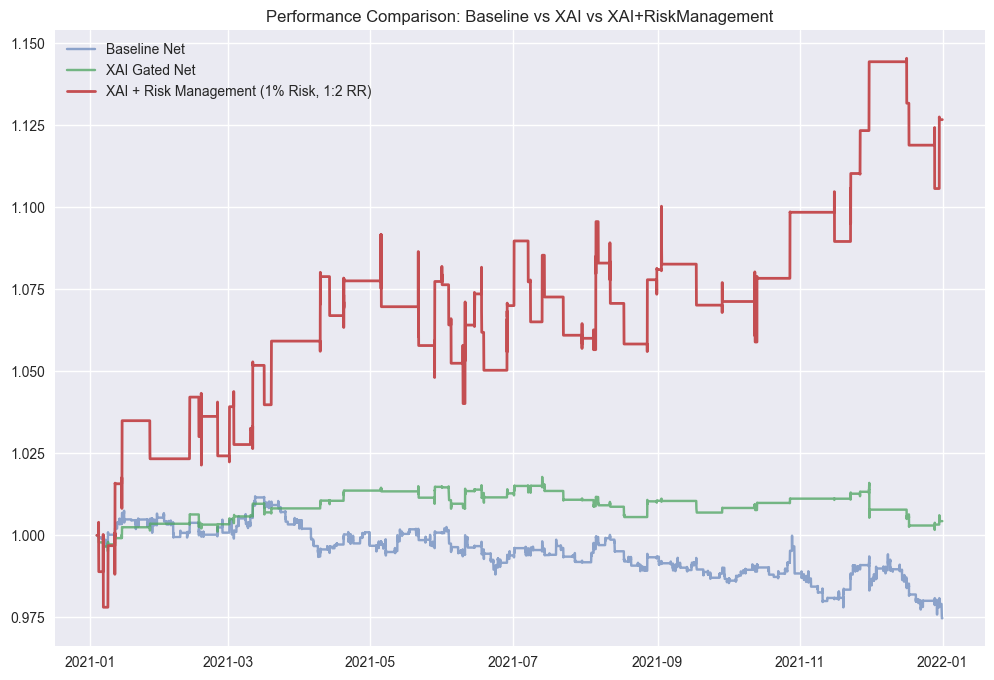


--- Risk Management System Performance ---
Final Capital: 112662.09
Total Trades: 62
Win Rate: 50.00%
Avg Win: 1492.96
Avg Loss: -1084.51
Risk:Reward Realized: 1.38


In [63]:

# -------------------------------------------------------------------------------------
# RISK MANAGEMENT SYSTEM IMPLEMENTATION
# -------------------------------------------------------------------------------------
# Logic:
# 1. Capital: 100,000
# 2. Risk per Trade: 1% of Capital
# 3. Position Sizing: Risk Amount / (Entry - SL)
# 4. Target: 1:2 Risk:Reward Ratio
# 5. Stop Loss: Dynamic based on Volatility (2 * Volatility * Price) - Proxy for "Quant" approach

INITIAL_CAPITAL = 100000
RISK_PCT = 0.01
REWARD_RATIO = 2.0
LEVERAGE_CAP = 30 # Safety cap
PTC = 0.00005 # Transaction cost rate from previous cells

class RiskManagedBacktest:
    def __init__(self, df, signal_col="position_xai", price_col="price", vol_col="vol"):
        self.df = df
        self.signal_col = signal_col
        self.price_col = price_col
        self.vol_col = vol_col
        self.capital = INITIAL_CAPITAL
        self.equity = [INITIAL_CAPITAL]
        self.trades_list = []
        
    def run(self):
        # State
        position = 0 # 0, 1, -1
        entry_price = 0.0
        stop_loss = 0.0
        take_profit = 0.0
        qty = 0
        
        # We start from index 1 to allow looking at previous signal
        for i in range(1, len(self.df)):
            idx = self.df.index[i]
            
            # Current Market Data
            current_price = self.df[self.price_col].iloc[i]
            current_vol = self.df[self.vol_col].iloc[i]
            current_signal = self.df[self.signal_col].iloc[i]
            
            # Previous Signal (to detect changes)
            prev_signal = self.df[self.signal_col].iloc[i-1]
            
            # 1. MANAGE EXISTING TRADE (SL/TP)
            if position != 0:
                # Check for SL Hit (Assume hit at SL level)
                sl_hit = (position == 1 and current_price <= stop_loss) or \
                         (position == -1 and current_price >= stop_loss)
                
                # Check for TP Hit (Assume hit at TP level)
                tp_hit = (position == 1 and current_price >= take_profit) or \
                         (position == -1 and current_price <= take_profit)
                
                # Check for Signal Reversal/Exit (XAI Strategy says get out)
                # Exit if signal goes to 0 or flips direction
                sig_exit = (current_signal == 0) or (current_signal != position)
                
                exit_price = None
                exit_reason = None
                
                if sl_hit:
                    exit_price = stop_loss
                    exit_reason = "SL"
                elif tp_hit:
                    exit_price = take_profit
                    exit_reason = "TP"
                elif sig_exit:
                    exit_price = current_price
                    exit_reason = "Signal"
                
                if exit_price is not None:
                    # Calculate PnL
                    # Gross PnL
                    trade_pnl = (exit_price - entry_price) * qty * position
                    # Transaction Costs (Entry + Exit) ~ Estimated
                    commission = (qty * entry_price * PTC) + (qty * exit_price * PTC)
                    
                    net_pnl = trade_pnl - commission
                    self.capital += net_pnl
                    
                    self.trades_list.append({
                        "Entry Time": entry_time,
                        "Exit Time": idx,
                        "Type": position,
                        "Entry Price": entry_price,
                        "Exit Price": exit_price,
                        "Reason": exit_reason,
                        "PnL": net_pnl,
                        "Return %": (net_pnl / (qty * entry_price)) * 100
                    })
                    
                    # Reset State
                    position = 0
                    qty = 0
            
            # 2. CHECK FOR NEW ENTRY
            # Only enter if currently flat AND signal has CHANGED to a new active state
            # (Matches XAI Gate logic: trade on events)
            if position == 0:
                if current_signal != 0 and current_signal != prev_signal:
                    # Logic to calculate Size
                    risk_amt = self.capital * RISK_PCT
                    
                    # Determine SL Distance
                    # Use 2 * Volatility (StdDev of Returns) * Price as proxy for ATR/Swing
                    # If Vol is too low, set min floor
                    sl_dist = current_price * current_vol * 2.0
                    if sl_dist < (current_price * 0.0005): # Min 5 pips approx
                        sl_dist = current_price * 0.0005
                        
                    if current_signal == 1:
                        stop_loss = current_price - sl_dist
                        take_profit = current_price + (sl_dist * REWARD_RATIO)
                    else:
                        stop_loss = current_price + sl_dist
                        take_profit = current_price - (sl_dist * REWARD_RATIO)
                        
                    # Calculate Quantity
                    # Risk = Qty * |Entry - SL|
                    # Qty = Risk / |Entry - SL|
                    if sl_dist > 0:
                        qty = risk_amt / sl_dist
                    else:
                        qty = 0
                        
                    # Leverage Check (Optional)
                    notional = qty * current_price
                    if notional > (self.capital * LEVERAGE_CAP):
                        qty = (self.capital * LEVERAGE_CAP) / current_price
                        
                    position = current_signal
                    entry_price = current_price
                    entry_time = idx
            
            # Record Equity Curve
            # Mark-to-market equity
            open_pnl = 0
            if position != 0:
                open_pnl = (current_price - entry_price) * qty * position
            
            self.equity.append(self.capital + open_pnl)
            
        return pd.Series(self.equity, index=self.df.index[len(self.df)-len(self.equity):])

# Run the RM Backtest
rm_backtest = RiskManagedBacktest(test, signal_col="position_xai")
test['equity_rm'] = rm_backtest.run()

# Normalize for comparison plot (Start at 1.0 like others)
test['cstrategy_rm_norm'] = test['equity_rm'] / INITIAL_CAPITAL

# Plotting Comparison
plt.figure(figsize=(12, 8))
plt.plot(test['cstrategy_net'], label='Baseline Net', alpha=0.6)
plt.plot(test['cstrategy_net_xai'], label='XAI Gated Net', alpha=0.8)
plt.plot(test['cstrategy_rm_norm'], label='XAI + Risk Management (1% Risk, 1:2 RR)', linewidth=2)
plt.title("Performance Comparison: Baseline vs XAI vs XAI+RiskManagement")
plt.legend()
plt.show()

# Statistics
trades_df = pd.DataFrame(rm_backtest.trades_list)
print("\n--- Risk Management System Performance ---")
print(f"Final Capital: {test['equity_rm'].iloc[-1]:.2f}")
print(f"Total Trades: {len(trades_df)}")
if len(trades_df) > 0:
    win_rate = len(trades_df[trades_df['PnL'] > 0]) / len(trades_df)
    avg_win = trades_df[trades_df['PnL'] > 0]['PnL'].mean()
    avg_loss = trades_df[trades_df['PnL'] <= 0]['PnL'].mean()
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Avg Win: {avg_win:.2f}")
    print(f"Avg Loss: {avg_loss:.2f}")
    print(f"Risk:Reward Realized: {abs(avg_win/avg_loss):.2f}")
else:
    print("No trades generated.")
